In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


iris_df=pd.read_csv("Iris.csv")
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
iris_df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [3]:
iris_df.shape

(150, 6)

In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


- The dataset contains 150 rows and 6 columns.
- It consists of 4 numerical features, 1 categorical target column (Species), and 1 ID column.
- All numerical features have valid values with no missing entries.

In [6]:
iris_df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

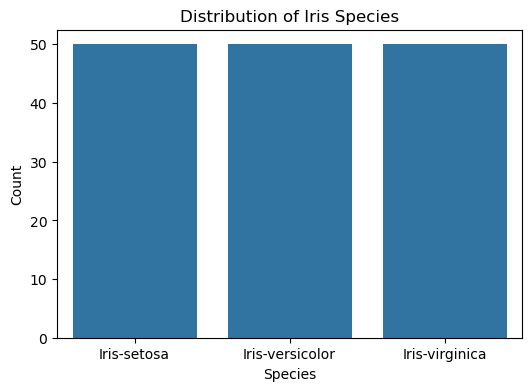

In [7]:
# Count Plot (Class Distribution)
plt.figure(figsize=(6,4))
sns.countplot(
    data=iris_df,
    x="Species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Results:

- Iris-setosa → 50
- Iris-versicolor → 50
- Iris-virginica → 50



- The count plot shows the distribution of the three Iris species in the dataset. Each species has an equal number of observations, with 50 samples each.

### Conclusion
- The dataset is perfectly balanced, as each Iris species contains 50 observations.
- There is no class imbalance, reducing the risk of bias during model training.
- Since all classes are equally represented, the dataset is well-suited for training and evaluating classification models.

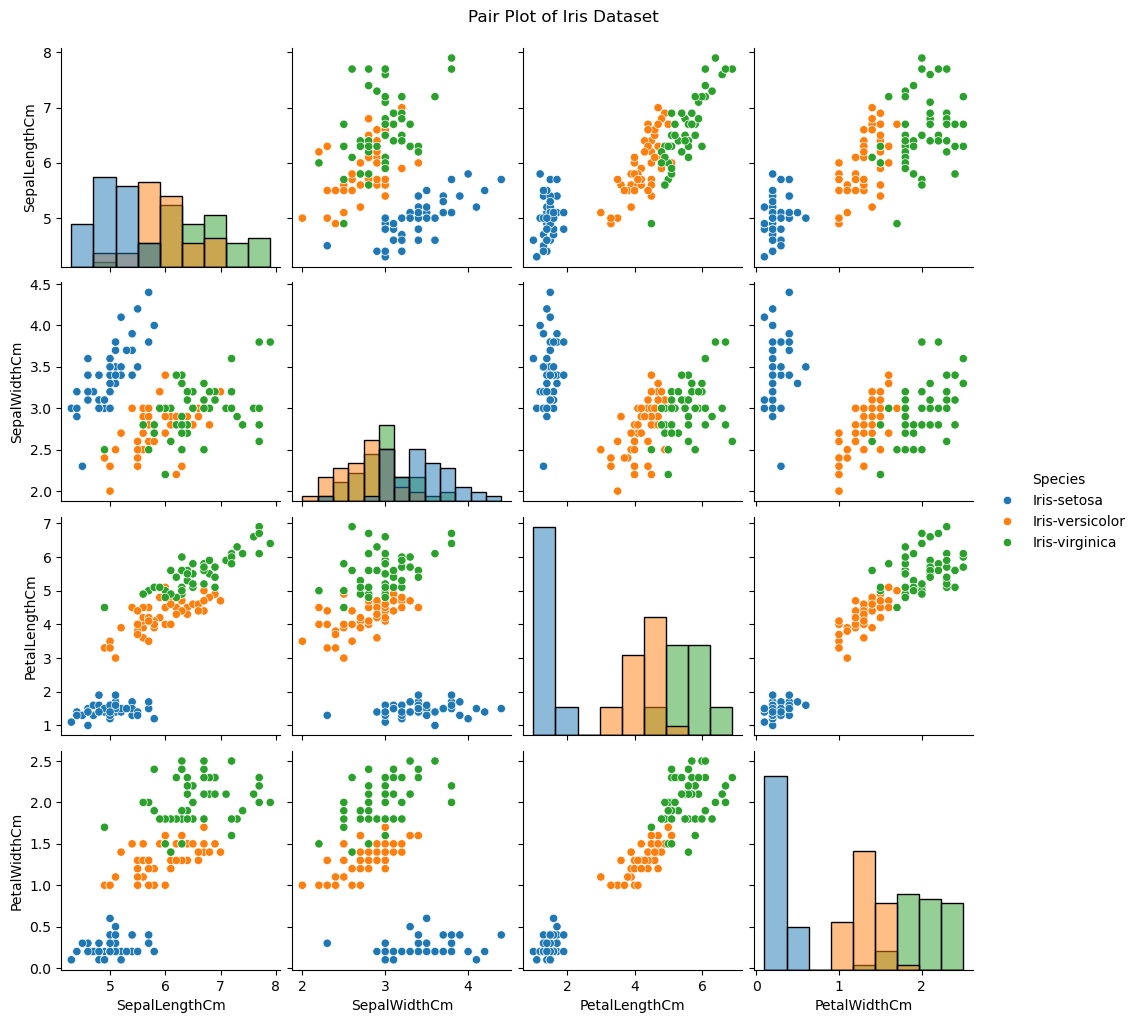

In [8]:
# Pair Plot

sns.pairplot(
    iris_df,
    hue="Species",
    vars=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
    diag_kind="hist"
)

plt.suptitle("Pair Plot of Iris Dataset", y=1.02)

plt.show()

## Results 
- Iris-setosa forms a completely separate cluster in almost all feature combinations.
- PetalLengthCm and PetalWidthCm clearly distinguish the three species.
- Iris-versicolor and Iris-virginica overlap slightly, especially when comparing sepal measurements.
- Sepal features show more overlap than petal features.

### Conclusion
- Petal measurements (PetalLengthCm and PetalWidthCm) are the most effective features for classifying Iris species.
- Sepal measurements alone are less effective because of the overlap between Iris-versicolor and Iris-virginica.
- The clear separation of Iris-setosa indicates that machine learning models are likely to classify this species with very high accuracy.
- Overall, the pair plot provides an excellent overview of feature distributions and relationships, making it one of the most informative visualizations in the exploratory data analysis (EDA) process.

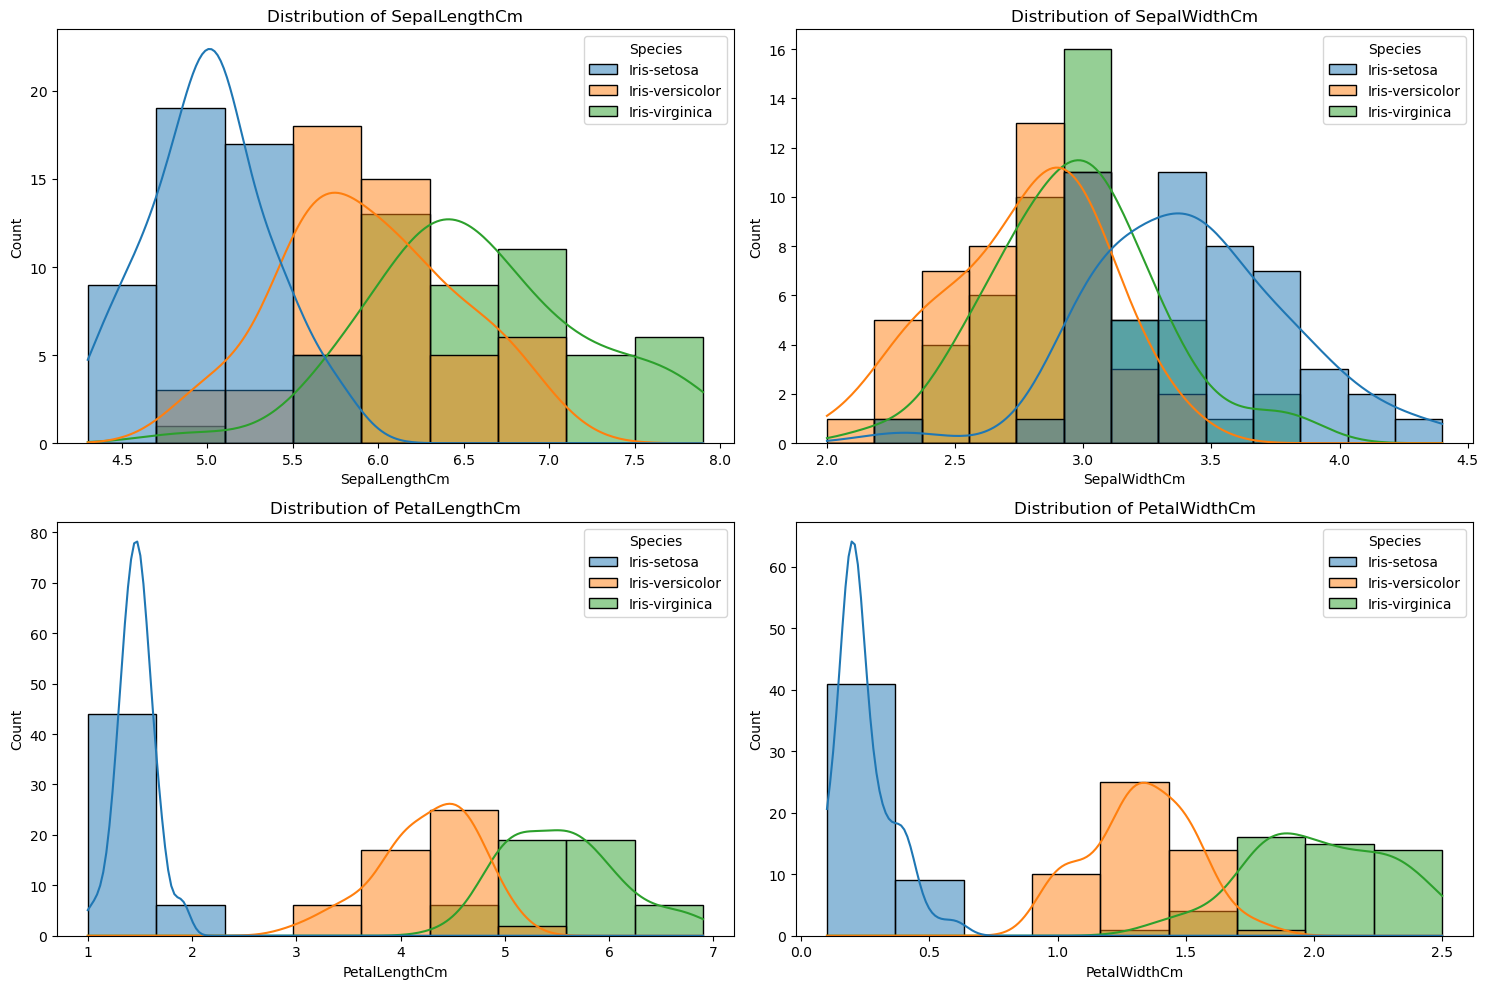

In [9]:
# Histogram - distribution of each numerical feature

features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=iris_df,
        x=feature,
        hue="Species",
        kde=True
    )
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

## Result
- PetalLengthCm and PetalWidthCm show three distinct distributions, making them highly useful for distinguishing the Iris species.
- SepalLengthCm shows moderate overlap between Iris-versicolor and Iris-virginica.
- SepalWidthCm has the highest overlap among the three species, making it less effective for classification.
- Iris-setosa generally has the smallest petal measurements, while Iris-virginica has the largest.


### Conclusion
- Petal measurements are the strongest features for differentiating Iris species.
- Sepal measurements contain more overlap and therefore provide less discriminative power.
- The presence of distinct distributions in petal features indicates that machine learning algorithms can classify the species effectively.
- Overall, the histogram confirms that the Iris dataset has well-defined feature distributions, especially for petal dimensions.


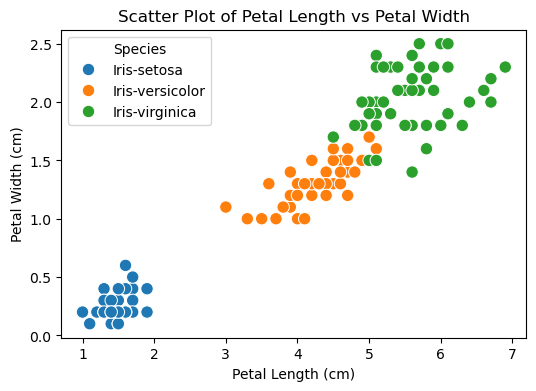

In [10]:
# Scatter Plot - relationship between Petal Length and Petal Width.

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=iris_df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=80
)

plt.title("Scatter Plot of Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

## Result
- Iris-setosa forms a completely separate cluster with the smallest petal length and width.
- Iris-versicolor occupies the middle range of petal measurements.
- Iris-virginica has the largest petal length and width values.
- A strong positive relationship is observed: as petal length increases, petal width also increases.
- There is slight overlap between Iris-versicolor and Iris-virginica, but they are still more distinguishable than with sepal features.

### Conclusion
- Petal Length and Petal Width are highly correlated and are the most effective features for classifying Iris species.
- Iris-setosa can be easily identified due to its distinct cluster.
- Although there is minor overlap between Iris-versicolor and Iris-virginica, these features still provide good separation.
- This visualization confirms that petal measurements will play a significant role in building accurate machine learning classification models.

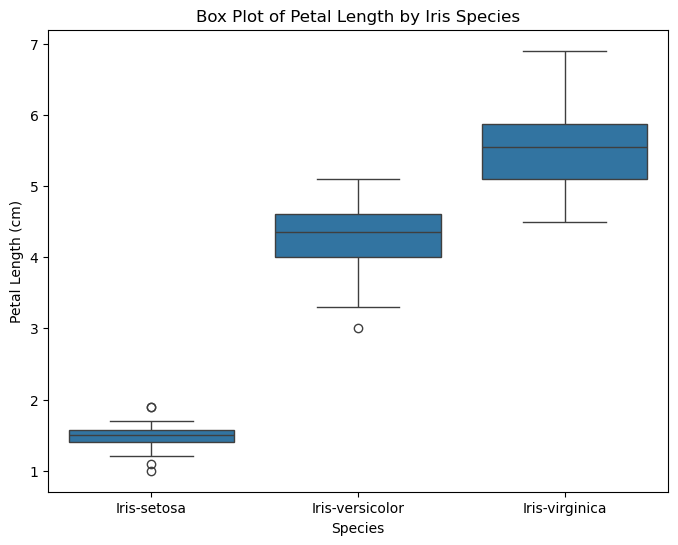

In [11]:
# Box Plot

plt.figure(figsize=(8,6))

sns.boxplot(
    data=iris_df,
    x="Species",
    y="PetalLengthCm"
)
plt.title("Box Plot of Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.show()

## Result
- Iris-setosa has the smallest petal lengths with very little variation.
- Iris-versicolor has moderate petal lengths.
- Iris-virginica has the largest petal lengths.
- There is minimal overlap between the species, especially between Setosa and the other two.
- The dataset contains a few outliers in Iris-setosa and Iris-versicolor, while Iris-virginica shows no significant outliers.

### Conclusion
- PetalLengthCm is one of the most discriminative features in the Iris dataset.
- The three species can be distinguished effectively based on their petal lengths.
- Although a few outliers are present in Setosa and Versicolor, they are very few and are unlikely to significantly affect machine - learning model performance.
- The clear separation between the medians of the three species suggests that this feature will contribute to high classification accuracy.

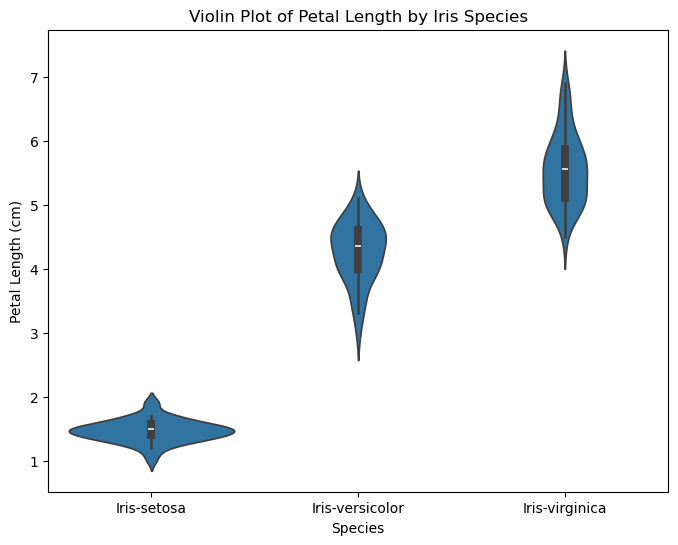

In [12]:
# Violin Plot - Density
plt.figure(figsize=(8,6))

sns.violinplot(
    data=iris_df,
    x="Species",
    y="PetalLengthCm"
)

plt.title("Violin Plot of Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.show()

##  Result
- Iris-setosa has the smallest petal lengths, while Iris-virginica has the largest, with Iris-versicolor in between.
- The distributions are mostly distinct, with only slight overlap between Iris-versicolor and Iris-virginica.
- Iris-virginica shows the greatest variation in petal length.

### Conclusion
- PetalLengthCm is a highly informative feature for distinguishing the three Iris species.
- The clear separation in distributions indicates that this feature will help improve the accuracy of machine learning classification models.

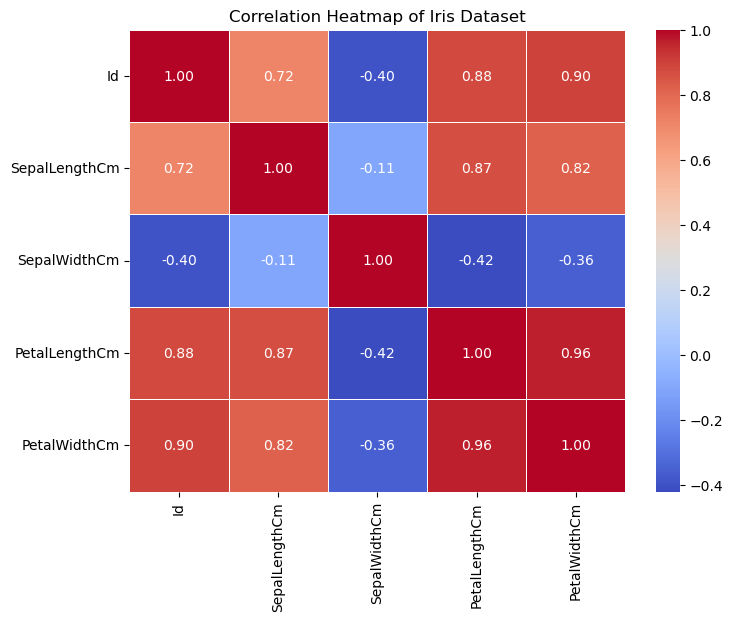

In [13]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    iris_df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Iris Dataset")

plt.show()

## Result
- PetalLengthCm and PetalWidthCm show the strongest positive correlation.
- SepalLengthCm is moderately correlated with petal measurements.
- SepalWidthCm has the weakest correlation with the other features.
## Conclusion
- PetalLengthCm and PetalWidthCm are the most strongly related features and are highly useful for classification.
- The heatmap confirms that petal measurements are more informative than sepal measurements for predicting the Iris species.

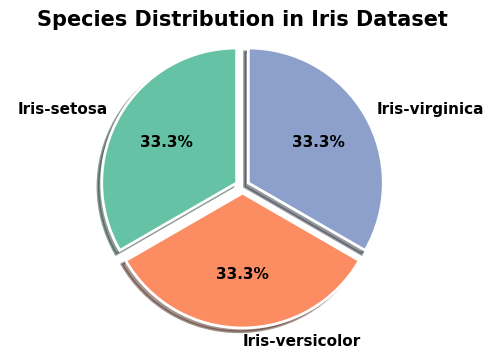

In [14]:
# pie chart distribution
species_count = iris_df["Species"].value_counts()

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(6,4))

plt.pie(
    species_count,
    labels=species_count.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    shadow=True,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

plt.title(
    "Species Distribution in Iris Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.axis("equal")
plt.show()

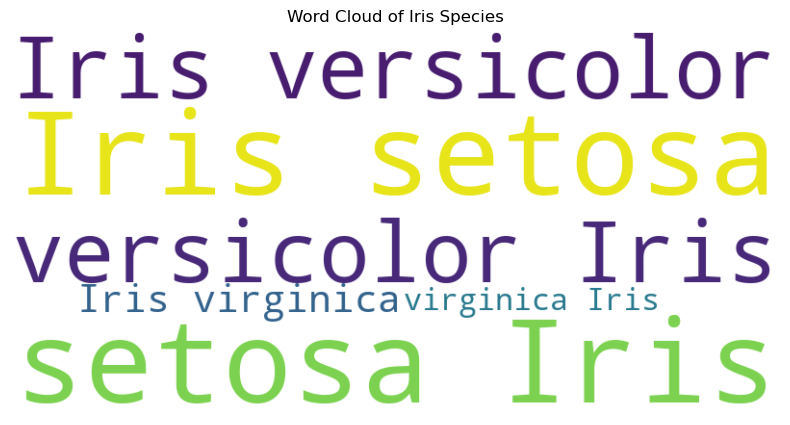

In [15]:
from wordcloud import WordCloud

text = " ".join(iris_df["Species"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Iris Species")

plt.show()

## *Machine Learning*

In [16]:
import pandas as pd
iris_d = pd.read_csv("iris.csv")
iris_d.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
#preprocessing
# converting 3 species into 0, 1, 2
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_d['Species'] = le.fit_transform(iris_d['Species'])

In [18]:
from sklearn.model_selection import train_test_split
X = iris_d.drop('Species', axis=1)
y = iris_d['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [19]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {'Logistic Regression': lr, 'KNN': knn, 'Naive Bayes': nb}

for name, model in models.items():
    y_pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, y_pred))
    
    print("cm:", confusion_matrix(y, y_pred))

    print("classification report:", classification_report(y, y_pred))


Logistic Regression
Accuracy: 1.0
cm: [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


KNN
Accuracy: 0.9933333333333333
cm: [[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.98      0.99        50
           2       0.98      1.00      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Naive Bayes
Accuracy: 0.9933333333333333

## Results
- Logistic Regression achieved the best performance with 100% accuracy.
- It correctly classified all 150 samples with no misclassifications.
- KNN achieved 99.33% accuracy with 1 misclassified sample.
- Naive Bayes achieved 99.33% accuracy with 1 misclassified sample.
- Overall, Logistic Regression is the best model for the Iris dataset.